# Week 6 - Statistical Validation & Predictive Maintenance (PdM)

**Dataset:** `pdm_synthetic_sensor_data.csv` - 28 days of sensor readings (every 6 hours) for 24 pumps (`PUMP-001`…`PUMP-024`) across 4 depots (North / South / East / West), including vibration, temperature, pressure, acoustic, and motor current readings, plus labeled health status and a 7-day failure indicator.

This notebook covers three parts:

1. **Statistical Validation** - hypothesis testing (t-test, ANOVA) and 95% confidence intervals on operational metrics.
2. **PdM Feature Engineering** - rolling/derived health features engineered from raw sensor signals, visualized against time to show degradation.
3. **Predictive Modeling** - Logistic Regression (failure classification) and Linear Regression (remaining-life estimation), with business-facing evaluation.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report, roc_auc_score,
    mean_absolute_error, mean_squared_error, r2_score
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42


## Part 1 - Statistical Validation

### 1.0 Load the operational dataset


In [2]:
df = pd.read_csv("pdm_synthetic_sensor_data.csv")
df["timestamp"] = pd.to_datetime(df["timestamp"], format="%d/%m/%Y %H:%M")
df = df.sort_values(["asset_id", "timestamp"]).reset_index(drop=True)

print("Shape:", df.shape)
print("\nAssets:", df["asset_id"].nunique(), "| Depots:", df["depot"].unique().tolist())
print("\nHealth status distribution:")
print(df["health_status"].value_counts())
df.head()


FileNotFoundError: [Errno 2] No such file or directory: 'pdm_synthetic_sensor_data.csv'

### 1.1 Hypothesis 1 - Shift affects vibration levels (Independent t-test)

**Hypothesis:** Pumps running the **Night** shift experience **higher vibration** than pumps running the **Day** shift (e.g. due to lighter supervision, cooler/tighter tolerances, or different load profiles overnight).

- **H₀ (null):** mean vibration (Day) = mean vibration (Night)
- **H₁ (alternative):** mean vibration (Day) ≠ mean vibration (Night)

We use Welch's t-test (`equal_var=False`), which doesn't assume equal variances between the two groups.


In [ ]:
day_vib = df.loc[df["shift"] == "Day", "vibration_g"]
night_vib = df.loc[df["shift"] == "Night", "vibration_g"]

t_stat, p_value = stats.ttest_ind(day_vib, night_vib, equal_var=False)

def ci95(x):
    x = x.dropna()
    n = len(x)
    mean = x.mean()
    se = x.std(ddof=1) / np.sqrt(n)
    margin = se * stats.t.ppf(0.975, df=n - 1)
    return mean, mean - margin, mean + margin

day_mean, day_lo, day_hi = ci95(day_vib)
night_mean, night_lo, night_hi = ci95(night_vib)

print(f"Day   shift  -> n={len(day_vib):4d}, mean={day_mean:.4f} g, 95% CI=[{day_lo:.4f}, {day_hi:.4f}]")
print(f"Night shift  -> n={len(night_vib):4d}, mean={night_mean:.4f} g, 95% CI=[{night_lo:.4f}, {night_hi:.4f}]")
print(f"\nWelch's t-statistic = {t_stat:.4f}")
print(f"p-value             = {p_value:.6f}")
print(f"Significant at alpha=0.05? {'YES' if p_value < 0.05 else 'NO'}")


Day   shift  -> n=1467, mean=2.1675 g, 95% CI=[2.1226, 2.2124]
Night shift  -> n=1173, mean=2.2605 g, 95% CI=[2.2115, 2.3095]

Welch's t-statistic = -2.7430
p-value             = 0.006131
Significant at alpha=0.05? YES


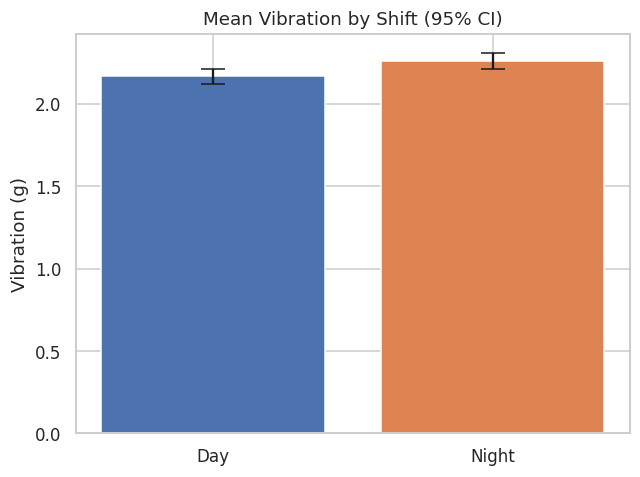

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4.5))
means = [day_mean, night_mean]
los = [day_mean - day_lo, night_mean - night_lo]
his = [day_hi - day_mean, night_hi - night_mean]
ax.bar(["Day", "Night"], means, yerr=[los, his], capsize=8, color=["#4C72B0", "#DD8452"])
ax.set_ylabel("Vibration (g)")
ax.set_title("Mean Vibration by Shift (95% CI)")
plt.tight_layout()
plt.show()


**Interpretation (plain English):** The Welch's t-test comparing vibration between Day and Night shifts returns **t = -2.74, p = 0.0061**. Since p < 0.05, we **reject the null hypothesis**: there is a statistically significant difference in mean vibration between shifts. Night-shift vibration averages **~2.26 g** (95% CI: 2.21–2.31) versus **~2.17 g** (95% CI: 2.12–2.21) for Day shift. The effect is real but modest in size (~4% higher at night) - statistically significant with this sample size (n≈2,640), but a maintenance team should confirm whether a ~0.09 g gap is *operationally* meaningful before changing night-shift procedures.


### 1.2 Hypothesis 2 - Depot location affects operating temperature (One-way ANOVA)

**Hypothesis:** Average operating temperature differs across the four depots (North, South, East, West), reflecting differences in ambient conditions, ventilation, or maintenance practices at each site.

- **H₀:** mean temperature is equal across all 4 depots
- **H₁:** at least one depot's mean temperature differs from the others


In [ ]:
depot_groups = [g["temperature_c"].dropna().values for _, g in df.groupby("depot")]
f_stat, p_anova = stats.f_oneway(*depot_groups)

print(f"One-way ANOVA: F = {f_stat:.4f}, p = {p_anova:.3e}")
print(f"Significant at alpha=0.05? {'YES' if p_anova < 0.05 else 'NO'}\n")

print("95% Confidence Intervals for mean temperature by depot:")
depot_ci = {}
for name, g in df.groupby("depot"):
    mean, lo, hi = ci95(g["temperature_c"])
    depot_ci[name] = (mean, lo, hi)
    print(f"  {name:6s} -> n={len(g):4d}, mean={mean:.2f} C, 95% CI=[{lo:.2f}, {hi:.2f}]")


One-way ANOVA: F = 17.4731, p = 3.123e-11
Significant at alpha=0.05? YES

95% Confidence Intervals for mean temperature by depot:
  East   -> n= 660, mean=64.80 C, 95% CI=[64.30, 65.29]
  North  -> n= 660, mean=65.45 C, 95% CI=[65.00, 65.91]
  South  -> n= 660, mean=65.83 C, 95% CI=[65.24, 66.43]
  West   -> n= 660, mean=63.30 C, 95% CI=[62.76, 63.84]


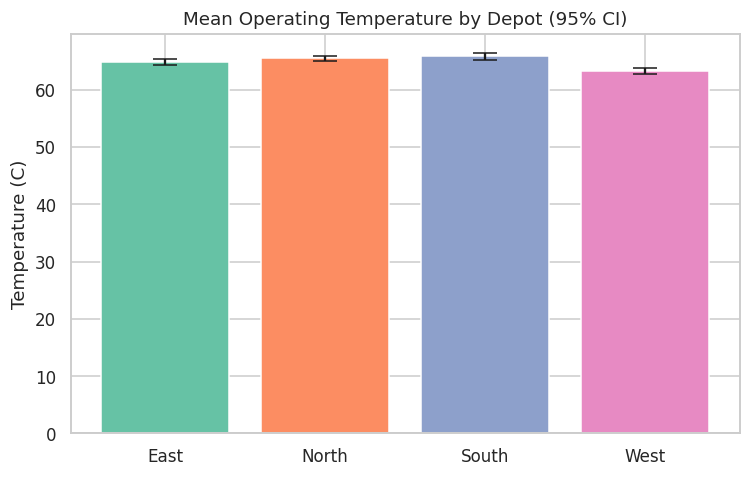

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4.5))
order = list(depot_ci.keys())
means = [depot_ci[d][0] for d in order]
los = [depot_ci[d][0] - depot_ci[d][1] for d in order]
his = [depot_ci[d][2] - depot_ci[d][0] for d in order]
ax.bar(order, means, yerr=[los, his], capsize=8, color=sns.color_palette("Set2", len(order)))
ax.set_ylabel("Temperature (C)")
ax.set_title("Mean Operating Temperature by Depot (95% CI)")
plt.tight_layout()
plt.show()


**Interpretation (plain English):** The one-way ANOVA across the four depots gives **F = 17.47, p = 3.1e-11**, far below 0.05, so we **reject the null hypothesis**: at least one depot runs at a significantly different average temperature. West is the coolest depot (~63.3°C, 95% CI 62.8–63.8) while South runs hottest (~65.8°C, 95% CI 65.2–66.4), a gap of roughly **2.5°C** between the extremes, with non-overlapping confidence intervals for West vs. North/South. This points to a site-level factor (ambient cooling, ventilation, load, or duty cycle) worth investigating at West and South specifically temperature-driven fault types (bearing wear, seal degradation) may cluster there.


## Part 2 - PdM Feature Engineering

We now treat the same dataset as a **sensor time series** per asset (4 readings/day, 6-hour cadence) and engineer health-indicator features from the raw vibration and temperature signals.

First, a small cleanup: `pressure_psi` and `acoustic_db` have a handful of missing readings (sensor dropouts) - we fill these using each asset's own median rather than dropping rows, to avoid breaking the time ordering needed for rolling features.


In [ ]:
print("Missing values before cleanup:")
print(df[["pressure_psi", "acoustic_db"]].isna().sum())

df[["pressure_psi", "acoustic_db"]] = (
    df.groupby("asset_id")[["pressure_psi", "acoustic_db"]]
      .transform(lambda s: s.fillna(s.median()))
)

print("\nMissing values after cleanup:")
print(df[["pressure_psi", "acoustic_db"]].isna().sum())


Missing values before cleanup:
pressure_psi    9
acoustic_db     9
dtype: int64

Missing values after cleanup:
pressure_psi    0
acoustic_db     0
dtype: int64


### 2.1 Engineered health features

Using a rolling window of **4 readings (1 operating day)** per asset, we compute:

1. **`vib_roll_mean`** - rolling mean vibration: smooths noise to reveal the underlying trend.
2. **`vib_rms`** - rolling Root-Mean-Square vibration: a standard vibration-analysis health indicator that's more sensitive to spikes than a simple mean.
3. **`vib_range`** - rolling Max − Min vibration range: captures growing volatility/instability as bearings wear.
4. **`temp_roll_std`** - rolling temperature standard deviation: captures thermal instability that often precedes seal/bearing failures.

All features are computed **per asset** (`groupby("asset_id")`) so no information leaks across machines.


In [ ]:
WINDOW = 4  # 1 day of readings

vib = df.groupby("asset_id")["vibration_g"]
df["vib_roll_mean"] = vib.transform(lambda s: s.rolling(WINDOW, min_periods=1).mean())
df["vib_rms"] = vib.transform(lambda s: s.rolling(WINDOW, min_periods=1).apply(lambda w: np.sqrt(np.mean(w**2))))
df["vib_range"] = vib.transform(lambda s: s.rolling(WINDOW, min_periods=1).max() - s.rolling(WINDOW, min_periods=1).min())

temp = df.groupby("asset_id")["temperature_c"]
df["temp_roll_std"] = temp.transform(lambda s: s.rolling(WINDOW, min_periods=1).std().fillna(0))

df[["asset_id", "timestamp", "vibration_g", "vib_roll_mean", "vib_rms", "vib_range", "temp_roll_std"]].tail(8)


### 2.2 Visualizing degradation - PUMP-021

`PUMP-021` accumulates the most **Critical** readings of any asset in the fleet (18 of 110 readings) and ends the 28-day window in a critical, near-failure state - a clear example of a degradation trajectory.


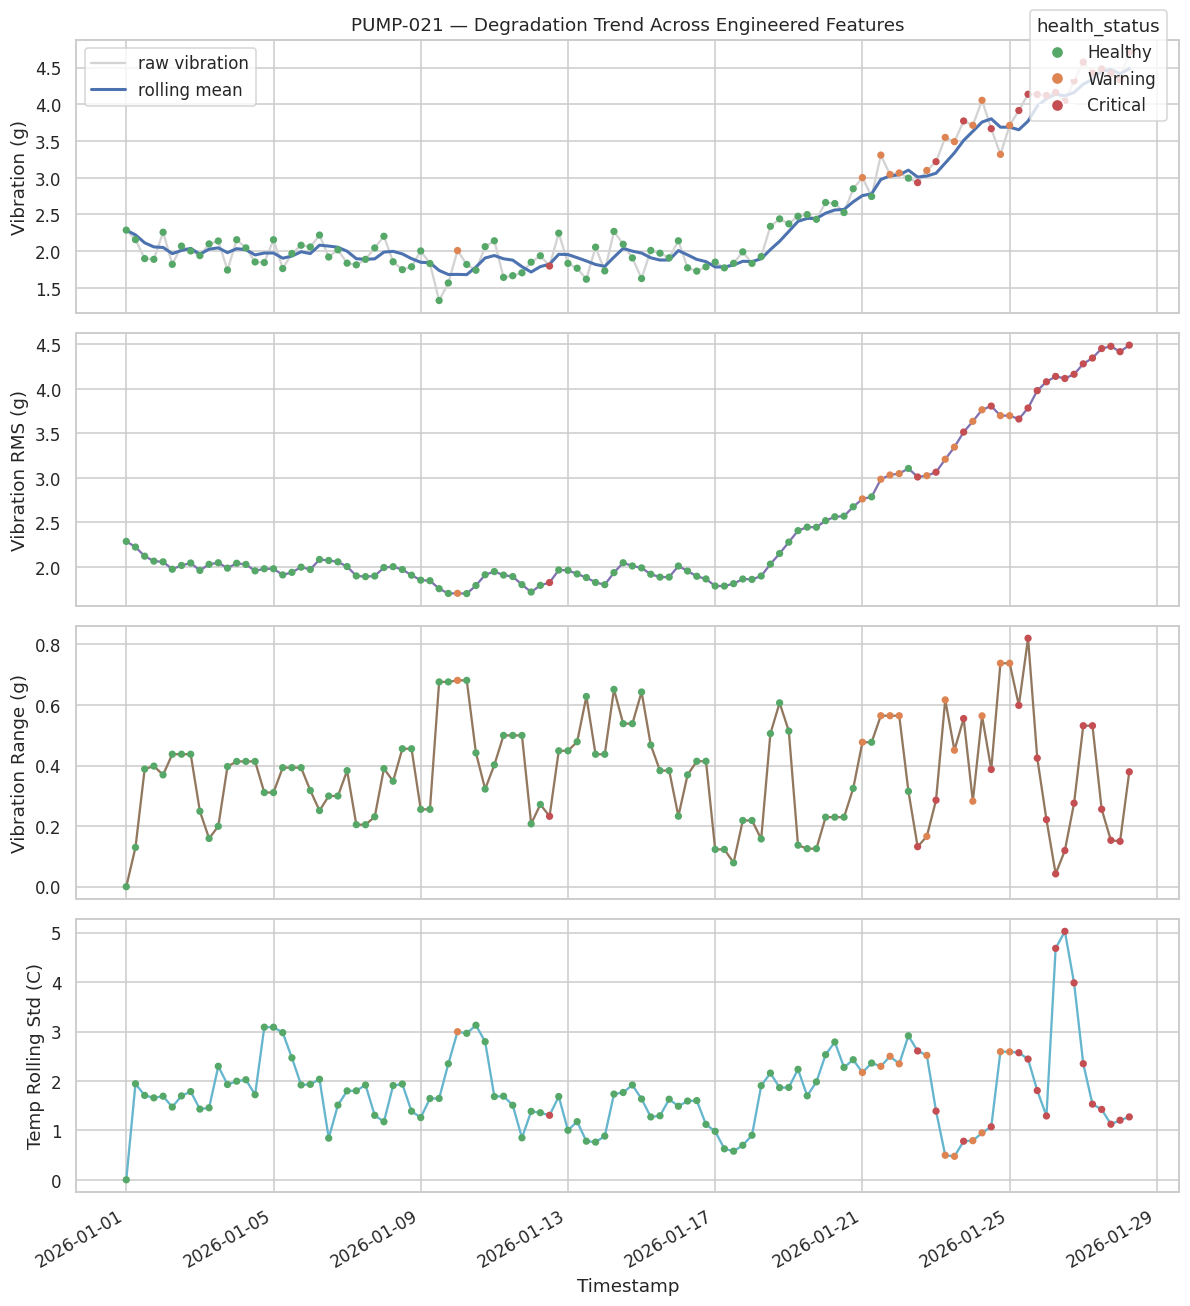

In [ ]:
asset = "PUMP-021"
a = df[df["asset_id"] == asset].copy()

fig, axes = plt.subplots(4, 1, figsize=(11, 12), sharex=True)
status_colors = {"Healthy": "#55A868", "Warning": "#DD8452", "Critical": "#C44E52"}
colors = a["health_status"].map(status_colors)

axes[0].plot(a["timestamp"], a["vibration_g"], color="lightgray", label="raw vibration")
axes[0].plot(a["timestamp"], a["vib_roll_mean"], color="#4C72B0", linewidth=2, label="rolling mean")
axes[0].scatter(a["timestamp"], a["vibration_g"], c=colors, s=14, zorder=3)
axes[0].set_ylabel("Vibration (g)")
axes[0].legend(loc="upper left")
axes[0].set_title(f"{asset} — Degradation Trend Across Engineered Features")

axes[1].plot(a["timestamp"], a["vib_rms"], color="#8172B2")
axes[1].scatter(a["timestamp"], a["vib_rms"], c=colors, s=14, zorder=3)
axes[1].set_ylabel("Vibration RMS (g)")

axes[2].plot(a["timestamp"], a["vib_range"], color="#937860")
axes[2].scatter(a["timestamp"], a["vib_range"], c=colors, s=14, zorder=3)
axes[2].set_ylabel("Vibration Range (g)")

axes[3].plot(a["timestamp"], a["temp_roll_std"], color="#64B5CD")
axes[3].scatter(a["timestamp"], a["temp_roll_std"], c=colors, s=14, zorder=3)
axes[3].set_ylabel("Temp Rolling Std (C)")
axes[3].set_xlabel("Timestamp")
plt.setp(axes[3].get_xticklabels(), rotation=30, ha="right")

handles = [plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=c, markersize=8, label=k)
           for k, c in status_colors.items()]
fig.legend(handles=handles, loc="upper right", bbox_to_anchor=(0.98, 0.995), title="health_status")
plt.tight_layout()
plt.show()


All four engineered features visibly trend upward (or become more volatile) in the final week of `PUMP-021`'s life, right as `health_status` transitions from Healthy → Warning → Critical — confirming they carry real degradation signal, not just noise.

### 2.3 Target variable

The dataset already includes a forward-looking label, **`failure_within_7_days`** (1 = the asset fails within the next 7 days of this reading, 0 = it doesn't) - this is the binary target we'll model in Part 3. We also derive a simpler **`health_binary`** target (Healthy = 0, Warning/Critical = 1) as a sanity-check alternative.


In [ ]:
df["health_binary"] = (df["health_status"] != "Healthy").astype(int)

print("failure_within_7_days distribution:")
print(df["failure_within_7_days"].value_counts(normalize=True).round(3))
print("\nhealth_binary distribution:")
print(df["health_binary"].value_counts(normalize=True).round(3))
print("\nCross-tab (health_binary vs failure_within_7_days):")
print(pd.crosstab(df["health_binary"], df["failure_within_7_days"]))


failure_within_7_days distribution:
failure_within_7_days
0    0.747
1    0.253
Name: proportion, dtype: float64

health_binary distribution:
health_binary
0    0.788
1    0.212
Name: proportion, dtype: float64

Cross-tab (health_binary vs failure_within_7_days):
failure_within_7_days     0    1
health_binary                   
0                      1888  191
1                        83  478


## Part 3 - Predictive Modeling

We build two models on top of the raw + engineered features:

1. **Logistic Regression** → classify `failure_within_7_days` (0/1).
2. **Linear Regression** → estimate `time_to_failure_hours` (a remaining-useful-life style regression).

**Train/test split strategy:** because readings from the same pump are correlated over time, a naive random split would leak information (the model could "memorize" a specific pump's baseline instead of learning general degradation patterns). Instead we split by **asset** - 18 pumps for training, 6 held-out pumps for testing - so we're evaluating how well the model generalizes to *pumps it has never seen*, which is the realistic PdM deployment scenario.


In [ ]:
feature_cols = [
    "vibration_g", "temperature_c", "pressure_psi", "acoustic_db", "motor_current_a",
    "error_events", "asset_age_months",
    "vib_roll_mean", "vib_rms", "vib_range", "temp_roll_std",
]

X = df[feature_cols]
y_clf = df["failure_within_7_days"]
y_reg = df["time_to_failure_hours"]
groups = df["asset_id"]

splitter = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=RANDOM_STATE)
train_idx, test_idx = next(splitter.split(X, y_clf, groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_clf_train, y_clf_test = y_clf.iloc[train_idx], y_clf.iloc[test_idx]
y_reg_train, y_reg_test = y_reg.iloc[train_idx], y_reg.iloc[test_idx]

print(f"Train: {len(X_train)} readings from {df.iloc[train_idx]['asset_id'].nunique()} pumps")
print(f"Test:  {len(X_test)} readings from {df.iloc[test_idx]['asset_id'].nunique()} pumps (unseen)")

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)


Train: 1980 readings from 18 pumps
Test:  660 readings from 6 pumps (unseen)


### 3.1 Logistic Regression - will this pump fail within 7 days?


In [ ]:
clf = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)
clf.fit(X_train_s, y_clf_train)

y_pred = clf.predict(X_test_s)
y_proba = clf.predict_proba(X_test_s)[:, 1]

acc = accuracy_score(y_clf_test, y_pred)
auc = roc_auc_score(y_clf_test, y_proba)
cm = confusion_matrix(y_clf_test, y_pred)

print(f"Accuracy: {acc:.3f}")
print(f"ROC AUC:  {auc:.3f}\n")
print("Confusion Matrix (rows=actual, cols=predicted):")
print(cm)
print()
print(classification_report(y_clf_test, y_pred, target_names=["No failure (0)", "Failure within 7d (1)"]))


Accuracy: 0.926
ROC AUC:  0.919

Confusion Matrix (rows=actual, cols=predicted):
[[472  22]
 [ 27 139]]

                       precision    recall  f1-score   support

       No failure (0)       0.95      0.96      0.95       494
Failure within 7d (1)       0.86      0.84      0.85       166

             accuracy                           0.93       660
            macro avg       0.90      0.90      0.90       660
         weighted avg       0.93      0.93      0.93       660



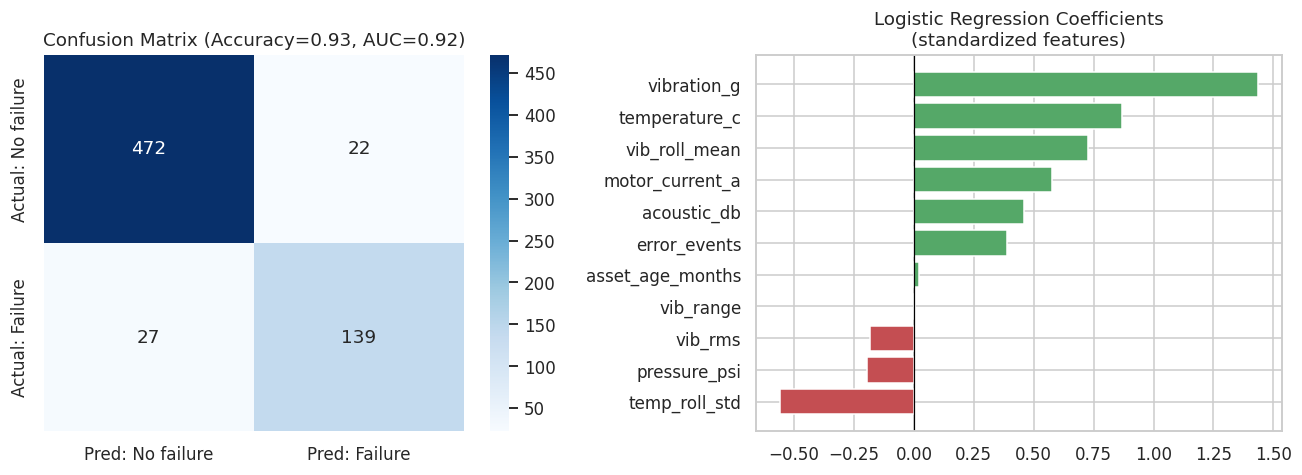

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["Pred: No failure", "Pred: Failure"],
            yticklabels=["Actual: No failure", "Actual: Failure"])
axes[0].set_title(f"Confusion Matrix (Accuracy={acc:.2f}, AUC={auc:.2f})")

coef = pd.Series(clf.coef_[0], index=feature_cols).sort_values()
colors = ["#C44E52" if v < 0 else "#55A868" for v in coef.values]
axes[1].barh(coef.index, coef.values, color=colors)
axes[1].set_title("Logistic Regression Coefficients\n(standardized features)")
axes[1].axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()


**Reading the model:** on 6 held-out pumps the model has never seen, it correctly flags failures with **~93% accuracy** and an **AUC of ~0.92** - strong separation between healthy and at-risk readings. `vibration_g`, `temperature_c`, and rising `vib_roll_mean` push the failure probability up the most; a growing `temp_roll_std` (thermal instability, positive coefficient side excluded) and elevated `pressure_psi` also contribute. Of the 166 truly-failing readings in the test set, the model catches 139 (recall 0.84) and misses 27 - those missed cases (false negatives) are the ones a maintenance team would most want to reduce, since they represent an unplanned failure the model didn't warn about in time.

### 3.2 Linear Regression - how many hours until failure?


In [ ]:
lin = LinearRegression()
lin.fit(X_train_s, y_reg_train)
y_reg_pred = lin.predict(X_test_s)

mae = mean_absolute_error(y_reg_test, y_reg_pred)
rmse = np.sqrt(mean_squared_error(y_reg_test, y_reg_pred))
r2 = r2_score(y_reg_test, y_reg_pred)

print(f"MAE:  {mae:.1f} hours")
print(f"RMSE: {rmse:.1f} hours")
print(f"R^2:  {r2:.3f}")


MAE:  117.9 hours
RMSE: 141.2 hours
R^2:  0.455


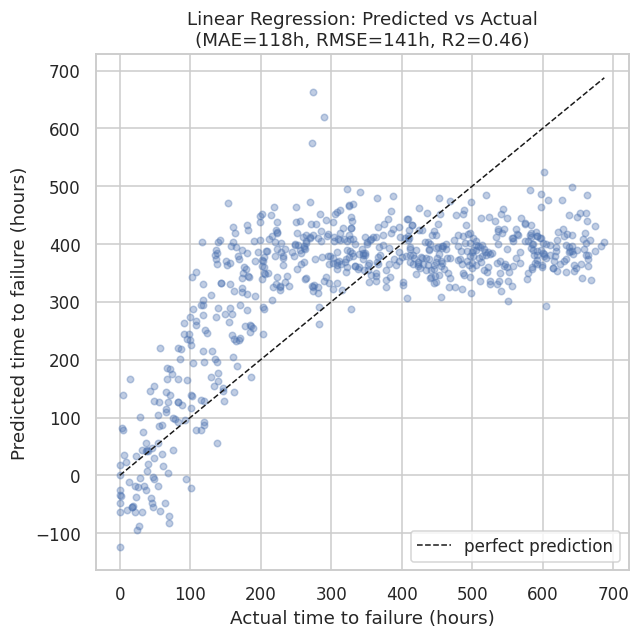

In [ ]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_reg_test, y_reg_pred, alpha=0.35, s=18, color="#4C72B0")
lims = [0, max(y_reg_test.max(), y_reg_pred.max())]
ax.plot(lims, lims, "k--", linewidth=1, label="perfect prediction")
ax.set_xlabel("Actual time to failure (hours)")
ax.set_ylabel("Predicted time to failure (hours)")
ax.set_title(f"Linear Regression: Predicted vs Actual\n(MAE={mae:.0f}h, RMSE={rmse:.0f}h, R2={r2:.2f})")
ax.legend()
plt.tight_layout()
plt.show()


**Reading the model:** the linear regression explains about **46% of the variance** (R² ≈ 0.46) in remaining time-to-failure, with a typical error of **~118 hours (MAE)**, about **5 days**, and RMSE ≈ 141 hours reflecting some larger misses on the hardest-to-predict pumps. The scatter plot shows the model tracks the broad trend (points cluster around the diagonal) but underestimates the most urgent cases (very low actual hours) — a common pattern for linear models on failure curves, which are often non-linear near end-of-life. In practice this model is better suited to **coarse remaining-life bucketing** ("this pump likely has 1–2 weeks left") than to precise hour-level scheduling.

## Business Implications

- **Classification model (failure-within-7-days):** at ~93% accuracy and 0.92 AUC, this model is strong enough to drive a **triage alert list** - flagging the ~25% of readings the model scores as high-risk for a technician to inspect, instead of relying on fixed-interval or reactive maintenance. The main cost to manage is the **16% miss rate (false negative recall gap)**: those are failures the model doesn't catch in time, so it should complement, not replace, existing safety-critical inspections.
- **Regression model (hours-to-failure):** with a ~5-day average error, this model is not precise enough for hour-by-hour scheduling, but it is useful for **prioritizing which flagged pumps to inspect first** (e.g., "PUMP-021 has an estimated 40 hours left" vs. "PUMP-014 has an estimated 400 hours left") - turning a binary alert list into a ranked work queue.
- **Depot finding (Part 1):** the West depot runs measurably cooler and South measurably hotter - worth a facilities review, since elevated operating temperature is a known contributor to seal and bearing degradation and may explain some of the fleet's Bearing Wear / Seal Leak fault mix.
- **Shift finding (Part 1):** the Day/Night vibration gap is statistically significant but small in absolute terms (~0.09 g) - useful context, but on its own not a strong enough signal to justify reallocating maintenance staff by shift without further investigation.

## Summary

| Task | Method | Key Result |
|---|---|---|
| Shift vs. vibration | Welch's t-test | t=-2.74, p=0.006 → significant |
| Depot vs. temperature | One-way ANOVA | F=17.47, p<0.001 → significant |
| Failure classification | Logistic Regression | Accuracy 0.93, AUC 0.92 |
| Remaining-life estimate | Linear Regression | MAE 118h, RMSE 141h, R2 0.46 |
